# Part 5 — Cell-Type Dissociation: RSU vs. FSU

Compares fast-spiking (FSU, narrow-waveform) and regular-spiking (RSU,
broad-waveform) unit populations on cross-mouse consistency, at both the
pooled-population level and the single-unit level, with a genetically
confirmed PV+ optotagged group as an independent reference throughout.

**Depends on:** `responses.h5`, `units_meta.parquet`, `manifest.json`, `part3_outputs.npz`
**Outputs saved:** `part5_outputs.npz` (RSU/FSU curves, consumed by Part 6)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
    unit_matched_sliding_curve,
    bootstrap_ts_difference,
)

import json
import gc
from itertools import combinations
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu, skew
from sklearn.linear_model import LinearRegression

SEED = 42
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')

colors      = apply_plot_style()
COL_DATA    = colors["COL_DATA"]
COL_FIT     = colors["COL_FIT"]
COL_REF     = colors["COL_REF"]
COL_RSU     = colors["COL_RSU"]
COL_FSU     = colors["COL_FSU"]
COL_FSU_PV  = colors["COL_FSU_PV"]
COL_HIGH_FSU_FRAC = colors["COL_HIGH_FSU_FRAC"]
COL_LOW_FSU_FRAC  = colors["COL_LOW_FSU_FRAC"]

In [2]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)
N_IMAGES       = manifest['n_images']
SESSION_IDS    = manifest['selected_session_ids_visp']
PV_SESSION_IDS = manifest['pv_cre_session_ids']   # subset of SESSION_IDS

p3 = np.load(OUTPUTS_DIR / 'part3_outputs.npz')
times_ms          = p3['times_ms'].tolist()
mean_c            = p3['mean_c']
window_centers_ms = p3['window_centers_ms'].tolist()
WINDOW_WIDTH_MS   = float(p3['window_width_ms'])
SLIDE_START_MS    = int(min(times_ms))
SLIDE_END_MS      = int(max(times_ms)) + 1
SUSTAINED_LO, SUSTAINED_HI = 220, 250
ts_ratio_all, pk_all, sus_all = ts_ratio(mean_c, np.array(times_ms))

units_meta = pd.read_parquet(ARCHIVE_DIR / 'units_meta.parquet')
units_visp = units_meta[units_meta['area'] == 'VISp'].copy()
print(f'VISp QC units: {len(units_visp)}  across {units_visp.ecephys_session_id.nunique()} sessions')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
VISp QC units: 3694  across 56 sessions


## 5.1 — Waveform-based RSU/FSU classification

A 2-component Gaussian mixture is fit on log waveform duration (trough to
peak). A unit is called FSU/RSU only if both (a) its posterior probability of
component membership exceeds `CONF_THRESH`, and (b) it falls within a
`CENTRAL_MASS` interval around that component's own mean (in units of that
component's own std). Everything else is `'ambiguous'` and excluded from
both groups.

In [3]:
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

CONF_THRESH  = 0.9   # posterior probability required to call a unit unambiguously FSU/RSU
CENTRAL_MASS = 0.9   # symmetric probability mass (around each component's own mean) kept per class

visp_wf = units_visp.dropna(subset=['waveform_duration']).copy()

gmm      = GaussianMixture(n_components=2, random_state=SEED, n_init=10)
X_wf     = visp_wf[['waveform_duration']].to_numpy()
X_wf_log = np.log(X_wf)
gmm.fit(X_wf_log)
post = gmm.predict_proba(X_wf_log)

narrow_comp = int(np.argmin(gmm.means_.ravel()))
broad_comp  = 1 - narrow_comp
p_narrow    = post[:, narrow_comp]
p_broad     = post[:, broad_comp]

mu_narrow,    mu_broad    = gmm.means_[narrow_comp, 0], gmm.means_[broad_comp, 0]
sigma_narrow, sigma_broad = (np.sqrt(gmm.covariances_[narrow_comp, 0, 0]),
                              np.sqrt(gmm.covariances_[broad_comp, 0, 0]))
z_bound = norm.ppf(0.5 + CENTRAL_MASS / 2)   # symmetric z capturing CENTRAL_MASS of a Gaussian

log_wf          = X_wf_log.ravel()
in_narrow_range = np.abs(log_wf - mu_narrow) <= z_bound * sigma_narrow
in_broad_range  = np.abs(log_wf - mu_broad)  <= z_bound * sigma_broad

visp_wf['p_narrow']   = p_narrow
visp_wf['p_broad']    = p_broad
visp_wf['cell_class'] = np.select(
    [(p_narrow >= CONF_THRESH) & in_narrow_range,
     (p_broad  >= CONF_THRESH) & in_broad_range],
    ['FSU', 'RSU'],
    default='ambiguous',
)

narrow_edge = visp_wf.loc[visp_wf['cell_class'] == 'FSU', 'waveform_duration'].max()
broad_edge  = visp_wf.loc[visp_wf['cell_class'] == 'RSU', 'waveform_duration'].min()
broad_hi    = visp_wf.loc[visp_wf['cell_class'] == 'RSU', 'waveform_duration'].max()

by_class = visp_wf.groupby(['ecephys_session_id', 'cell_class']).size().unstack(fill_value=0)
by_class = by_class.reindex(columns=['FSU', 'RSU', 'ambiguous'], fill_value=0)

n_fsu_total = (visp_wf['cell_class'] == 'FSU').sum()
n_rsu_total = (visp_wf['cell_class'] == 'RSU').sum()
n_amb_total = (visp_wf['cell_class'] == 'ambiguous').sum()
fsu_frac    = n_fsu_total / (n_fsu_total + n_rsu_total)

print(f'2-component GMM fit on log waveform duration (n={len(visp_wf)} QC units)')
print(f'Component means: narrow = {np.exp(mu_narrow):.3f} ms, broad = {np.exp(mu_broad):.3f} ms')
print(f'FSU: n={n_fsu_total}, RSU: n={n_rsu_total}, ambiguous: n={n_amb_total}')
print(f'Mean FSU / session: {by_class["FSU"].mean():.1f}, mean RSU / session: {by_class["RSU"].mean():.1f}')

2-component GMM fit on log waveform duration (n=3694 QC units)
Component means: narrow = 0.263 ms, broad = 0.627 ms
FSU: n=634, RSU: n=2777, ambiguous: n=283
Mean FSU / session: 11.3, mean RSU / session: 49.6


## 5.2 — Optotagged PV+ identification

Optotagged PV+ units are identified from the five Pvalb-IRES-Cre × Ai32
sessions using precomputed light/baseline response ratios in `units_meta`,
then merged with the waveform-based `cell_class` from 5.1.

In [4]:
OPTO_LIGHT_THRESH = 0.05
OPTO_RATIO_THRESH = 2.0

pv_units = units_visp[units_visp['ecephys_session_id'].isin(PV_SESSION_IDS)].copy()
pv_units['opto_ratio'] = (pv_units['opto_light_mean'] /
                           (pv_units['opto_baseline_mean'] + 1e-6))
pv_units['is_opto'] = ((pv_units['opto_light_mean'] > OPTO_LIGHT_THRESH) &
                        (pv_units['opto_ratio'] > OPTO_RATIO_THRESH))
pv_units = pv_units.merge(
    visp_wf[['ecephys_session_id', 'unit_id', 'cell_class']],
    on=['ecephys_session_id', 'unit_id'], how='left',
)

print('Optotagged PV+ units per session:')
for sid in PV_SESSION_IDS:
    sess   = pv_units[pv_units['ecephys_session_id'] == sid]
    tagged = sess[sess['is_opto']]
    print(f'  Session {sid}: {len(sess)} QC units, {len(tagged)} optotagged')

total_tagged = pv_units['is_opto'].sum()
n_broad_pv   = (pv_units[pv_units['is_opto']]['cell_class'] == 'RSU').sum()
n_amb_pv     = (pv_units[pv_units['is_opto']]['cell_class'] == 'ambiguous').sum()
print(f'Total optotagged: {total_tagged}, GMM-RSU-classified: {n_broad_pv}, ambiguous: {n_amb_pv}')

Optotagged PV+ units per session:
  Session 721123822: 41 QC units, 3 optotagged
  Session 746083955: 14 QC units, 1 optotagged
  Session 760345702: 72 QC units, 3 optotagged
  Session 773418906: 37 QC units, 1 optotagged
  Session 797828357: 85 QC units, 10 optotagged
Total optotagged: 18, GMM-RSU-classified: 3, ambiguous: 1


## 5.3 — Load response tensors

All 32 VISp QC sessions (including the 5 PV-Cre sessions, a subset) are
loaded once and reused across the pooled-population and single-unit
analyses below.

In [5]:
print('Loading VISp tensors...')
all_tensors = {}
with h5py.File(ARCHIVE_DIR / 'responses.h5', 'r') as f:
    for sid in SESSION_IDS:
        grp = f[f'natural_scenes/VISp/{sid}']
        all_tensors[sid] = {
            'tensor':   grp['tensor'][:],
            'unit_ids': grp['unit_ids'][:],
        }
print('Done.')

def curve_from_sliding(sl):
    ts = sorted(sl.keys())
    mc = np.array([sl[t].mean() for t in ts])
    return np.array(ts), mc

def peak_time(t, c):
    t = np.asarray(t); c = np.asarray(c)
    post_mask = (t >= 0) & (t <= 250)
    return t[post_mask][np.argmax(c[post_mask])]

Loading VISp tensors...
Done.


## 5.4 — Population-level sliding-window analysis

For each time window, response matrices are reconstructed for each cell
class separately by slicing the tensor to the appropriate unit columns.
Sessions must have at least `MIN_UNITS_SUBPOP` units of *both* classes to be
included, so RSU and FSU curves are computed over the identical session set.

In [6]:
MIN_UNITS_SUBPOP = 15

sess_rsu_idx = {}
sess_fsu_idx = {}
for sid in SESSION_IDS:
    uid_arr  = all_tensors[sid]['unit_ids']
    sess_wf  = visp_wf[visp_wf['ecephys_session_id'] == sid]
    rsu_keep = set(sess_wf.loc[sess_wf['cell_class'] == 'RSU', 'unit_id'])
    fsu_keep = set(sess_wf.loc[sess_wf['cell_class'] == 'FSU', 'unit_id'])
    rsu_idx  = [i for i, uid in enumerate(uid_arr) if uid in rsu_keep]
    fsu_idx  = [i for i, uid in enumerate(uid_arr) if uid in fsu_keep]
    if len(rsu_idx) >= MIN_UNITS_SUBPOP and len(fsu_idx) >= MIN_UNITS_SUBPOP:
        sess_rsu_idx[sid] = rsu_idx
        sess_fsu_idx[sid] = fsu_idx

rsu_sids = list(sess_rsu_idx.keys())
fsu_sids = list(sess_fsu_idx.keys())
print(f'RSU sessions: {len(rsu_sids)}, FSU sessions: {len(fsu_sids)}')

def sess_means_from_pairs(per_pair, pairs, n):
    means  = np.zeros(n)
    counts = np.zeros(n)
    for p_idx, (a, b) in enumerate(pairs):
        r = per_pair[p_idx].mean()
        means[a] += r;  counts[a] += 1
        means[b] += r;  counts[b] += 1
    return means / (counts + 1e-8)

sliding_rsu      = {}
sliding_fsu      = {}
sess_per_win_rsu = []
sess_per_win_fsu = []

for t_ms in window_centers_ms:
    t_lo = t_ms - WINDOW_WIDTH_MS / 2
    t_hi = t_ms + WINDOW_WIDTH_MS / 2

    mats_rsu = [window_response(all_tensors[sid]['tensor'][:, sess_rsu_idx[sid], :], t_lo, t_hi)
                for sid in rsu_sids]
    sims_rsu = compute_similarity_matrices(mats_rsu)
    c_rsu, per_pair_rsu, pairs_rsu = per_image_consistency(sims_rsu)
    sliding_rsu[t_ms] = c_rsu

    mats_fsu = [window_response(all_tensors[sid]['tensor'][:, sess_fsu_idx[sid], :], t_lo, t_hi)
                for sid in fsu_sids]
    sims_fsu = compute_similarity_matrices(mats_fsu)
    c_fsu, per_pair_fsu, pairs_fsu = per_image_consistency(sims_fsu)
    sliding_fsu[t_ms] = c_fsu

    sess_per_win_rsu.append(sess_means_from_pairs(per_pair_rsu, pairs_rsu, len(rsu_sids)))
    sess_per_win_fsu.append(sess_means_from_pairs(per_pair_fsu, pairs_fsu, len(fsu_sids)))

sess_curves_rsu = np.array(sess_per_win_rsu).T   # (n_rsu_sessions, n_windows)
sess_curves_fsu = np.array(sess_per_win_fsu).T   # (n_fsu_sessions, n_windows)

ts_rsu, mc_rsu = curve_from_sliding(sliding_rsu)
ts_fsu, mc_fsu = curve_from_sliding(sliding_fsu)
ts_ratio_rsu, pk_rsu, sus_rsu = ts_ratio(mc_rsu, ts_rsu)
ts_ratio_fsu, pk_fsu, sus_fsu = ts_ratio(mc_fsu, ts_fsu)
print(f'RSU — peak: {pk_rsu:.3f}, sustained: {sus_rsu:.3f}, T/S: {ts_ratio_rsu:.2f}')
print(f'FSU — peak: {pk_fsu:.3f}, sustained: {sus_fsu:.3f}, T/S: {ts_ratio_fsu:.2f}')

RSU sessions: 9, FSU sessions: 9
RSU — peak: 0.267, sustained: 0.167, T/S: 1.60
FSU — peak: 0.277, sustained: 0.131, T/S: 2.12


### 5.4b — Unit-count-matched control

Every RSU session's unit pool is subsampled down to that same session's own
FSU count (not a single count averaged across sessions), over many draws,
and the sliding-window curve / T/S ratio recomputed on the matched pool.

In [7]:
N_DRAWS_MATCH = 50

target_n_by_sid = {sid: len(sess_fsu_idx[sid]) for sid in rsu_sids}

rsu_tensors_only = {sid: all_tensors[sid]['tensor'] for sid in rsu_sids}
rsu_idx_only     = {sid: sess_rsu_idx[sid] for sid in rsu_sids}

(ts_rsu_match, mc_rsu_match, ci_lo_rsu_match, ci_hi_rsu_match,
 ts_draws_rsu_match) = unit_matched_sliding_curve(
    rsu_tensors_only, rsu_idx_only, target_n_by_sid,
    window_centers_ms, WINDOW_WIDTH_MS, n_draws=N_DRAWS_MATCH, seed=SEED,
)
ts_ratio_rsu_match, pk_rsu_match, sus_rsu_match = ts_ratio(mc_rsu_match, ts_rsu_match)

print(f'RSU matched (to each session\'s own FSU count) — '
      f'peak: {pk_rsu_match:.3f}, sustained: {sus_rsu_match:.3f}, T/S: {ts_ratio_rsu_match:.2f} '
      f'(draws: mean={ts_draws_rsu_match.mean():.2f}, '
      f'95% CI=[{np.percentile(ts_draws_rsu_match, 2.5):.2f}, '
      f'{np.percentile(ts_draws_rsu_match, 97.5):.2f}])')

RSU matched (to each session's own FSU count) — peak: 0.132, sustained: 0.065, T/S: 2.02 (draws: mean=2.05, 95% CI=[1.72, 2.44])


### 5.4c — Optotagged PV+ pooled sliding-window curve

Same pooled-population method as above, restricted to optotagged PV+ units
(sessions with fewer than `MIN_TAGGED_UNITS` optotagged units are excluded).

In [8]:
MIN_TAGGED_UNITS = 3

usable_pv_sids = {
    sid: pv_units.loc[(pv_units['ecephys_session_id'] == sid) & pv_units['is_opto'], 'unit_id'].tolist()
    for sid in PV_SESSION_IDS
}
usable_pv_sids = {sid: ids for sid, ids in usable_pv_sids.items() if len(ids) >= MIN_TAGGED_UNITS}
print(f'Sessions with >= {MIN_TAGGED_UNITS} optotagged units: {list(usable_pv_sids.keys())}')

sliding_pv = {}
for t_ms in window_centers_ms:
    t_lo = t_ms - WINDOW_WIDTH_MS / 2
    t_hi = t_ms + WINDOW_WIDTH_MS / 2
    mats = []
    for sid, opto_ids in usable_pv_sids.items():
        uid_arr = all_tensors[sid]['unit_ids']
        idx     = [i for i, uid in enumerate(uid_arr) if uid in set(opto_ids)]
        if len(idx) < 2:
            continue
        X = window_response(all_tensors[sid]['tensor'][:, idx, :], t_lo, t_hi)
        mats.append(X)
    if len(mats) >= 2:
        sims = compute_similarity_matrices(mats)
        c, _, _ = per_image_consistency(sims)
        sliding_pv[t_ms] = c

ts_pv, mc_pv = curve_from_sliding(sliding_pv)
ts_ratio_pv, pk_pv, sus_pv_val = ts_ratio(mc_pv, ts_pv)
print(f'Optotagged PV+ (pooled) — peak: {pk_pv:.3f}, sustained: {sus_pv_val:.3f}, T/S: {ts_ratio_pv:.2f}')

Sessions with >= 3 optotagged units: [721123822, 760345702, 797828357]
Optotagged PV+ (pooled) — peak: 0.223, sustained: 0.062, T/S: 3.59


## 5.5 — Single-unit cross-mouse consistency

Each QC unit is scored individually: its length-118 response vector (own
column, z-scored, 0-250 ms window) is run through the same cosine-similarity
+ Spearman-profile machinery as an `n_units=1` "session", and its consistency
averaged against every *other* session's full population profile. This gives
one cross-mouse-consistency number per unit, without pooling/subsampling
across units.

In [9]:
RESPONSE_WINDOW = (0.0, 250.0)
mask_img = ~np.eye(N_IMAGES, dtype=bool)

def ranked_profile(sim):
    """Rank-transform + mean-center each image's similarity-to-others profile
    (mirrors per_image_consistency's internal Spearman-prep)."""
    stripped = sim[mask_img].reshape(N_IMAGES, N_IMAGES - 1)
    order    = np.argsort(stripped, axis=1)
    ranked   = np.empty_like(order, dtype=float)
    np.put_along_axis(ranked, order, np.arange(N_IMAGES - 1), axis=1)
    return ranked - ranked.mean(1, keepdims=True)

def raw_window_response(tensor, t_lo_ms, t_hi_ms):
    """Summed (non-z-scored) spike counts per unit per image over a window,
    for magnitude/sparsity -- window_response z-scores, which erases both."""
    lo = np.searchsorted(bin_edges, t_lo_ms)
    hi = np.searchsorted(bin_edges, t_hi_ms)
    return tensor[:, :, lo:hi].sum(axis=2).astype(np.float32)

# Precompute each session's full-population ranked profile once.
pop_ranked = {}
for sid in SESSION_IDS:
    X_full = window_response(all_tensors[sid]['tensor'], *RESPONSE_WINDOW)
    S_full = compute_similarity_matrices([X_full])[0]
    pop_ranked[sid] = ranked_profile(S_full)

# Score every QC unit (known FSU/RSU class) against every other session's
# full-population profile, and record raw magnitude + lifetime sparseness
# (Rolls & Tovee) for the confound check in 5.5e.
visp_wf_sess   = visp_wf[visp_wf['ecephys_session_id'].isin(SESSION_IDS)]
unit_scores    = []
unit_classes   = []
unit_magnitude = []
unit_sparsity  = []

for sid in SESSION_IDS:
    uid_arr      = all_tensors[sid]['unit_ids']
    sess_wf      = visp_wf_sess[visp_wf_sess['ecephys_session_id'] == sid]
    class_by_uid = dict(zip(sess_wf['unit_id'], sess_wf['cell_class']))

    other_sids  = [s for s in SESSION_IDS if s != sid]
    other_stack = np.stack([pop_ranked[s] for s in other_sids])
    other_ss    = (other_stack ** 2).sum(2)

    raw_full = raw_window_response(all_tensors[sid]['tensor'], *RESPONSE_WINDOW)

    for j, uid in enumerate(uid_arr):
        cls = class_by_uid.get(uid)
        if cls not in ('FSU', 'RSU'):
            continue
        X_unit = window_response(all_tensors[sid]['tensor'][:, [j], :], *RESPONSE_WINDOW)
        S_unit = compute_similarity_matrices([X_unit])[0]
        r_unit = ranked_profile(S_unit)

        num = np.einsum('ik,oik->oi', r_unit, other_stack)
        den = np.sqrt((r_unit ** 2).sum(1)[None, :] * other_ss) + 1e-8
        per_image_corr = num / den

        r_raw     = raw_full[:, j]
        mean_sq   = (r_raw ** 2).mean()
        magnitude = r_raw.mean()
        sparsity  = ((1 - magnitude ** 2 / mean_sq) / (1 - 1 / N_IMAGES)
                     if mean_sq > 0 else np.nan)

        unit_scores.append(per_image_corr.mean())
        unit_classes.append(cls)
        unit_magnitude.append(magnitude)
        unit_sparsity.append(sparsity)

unit_scores    = np.array(unit_scores)
unit_classes   = np.array(unit_classes)
unit_magnitude = np.array(unit_magnitude)
unit_sparsity  = np.array(unit_sparsity)
fsu_scores     = unit_scores[unit_classes == 'FSU']
rsu_scores     = unit_scores[unit_classes == 'RSU']

u_stat, p_val = mannwhitneyu(fsu_scores, rsu_scores, alternative='two-sided')
print(f'Single-unit consistency ({RESPONSE_WINDOW[0]:.0f}-{RESPONSE_WINDOW[1]:.0f}ms window):')
print(f'  FSU: n={len(fsu_scores)}, median={np.median(fsu_scores):.4f}, mean={fsu_scores.mean():.4f}')
print(f'  RSU: n={len(rsu_scores)}, median={np.median(rsu_scores):.4f}, mean={rsu_scores.mean():.4f}')
print(f'  Mann-Whitney U={u_stat:.1f}, p={p_val:.2e}')

Single-unit consistency (0-250ms window):
  FSU: n=368, median=0.0874, mean=0.0946
  RSU: n=1499, median=0.0459, mean=0.0524
  Mann-Whitney U=407136.0, p=1.38e-45


### 5.5b — Single-unit consistency, full sliding window

Same per-unit method as 5.5a, repeated for every sliding window: each unit's
`n=1` similarity profile is scored against every other session's full
population profile in that same window, and FSU/RSU per-unit scores are
averaged into two temporal curves.

In [10]:
def ranked_profile_batch(sim_stack):
    """Batch version of ranked_profile for a stack of (n_items, n_images, n_images) similarity matrices."""
    n_items  = sim_stack.shape[0]
    stripped = sim_stack[:, mask_img].reshape(n_items, N_IMAGES, N_IMAGES - 1)
    order    = np.argsort(stripped, axis=2)
    ranked   = np.empty_like(order, dtype=float)
    np.put_along_axis(ranked, order, np.arange(N_IMAGES - 1), axis=2)
    return ranked - ranked.mean(2, keepdims=True)

su_sliding_fsu = {}
su_sliding_rsu = {}

for t_ms in window_centers_ms:
    t_lo = t_ms - WINDOW_WIDTH_MS / 2
    t_hi = t_ms + WINDOW_WIDTH_MS / 2

    pop_ranked_w = {}
    for sid in SESSION_IDS:
        X_full = window_response(all_tensors[sid]['tensor'], t_lo, t_hi)
        S_full = compute_similarity_matrices([X_full])[0]
        pop_ranked_w[sid] = ranked_profile(S_full)

    win_scores = {'FSU': [], 'RSU': []}
    for sid in SESSION_IDS:
        uid_arr      = all_tensors[sid]['unit_ids']
        sess_wf      = visp_wf_sess[visp_wf_sess['ecephys_session_id'] == sid]
        class_by_uid = dict(zip(sess_wf['unit_id'], sess_wf['cell_class']))
        sel = [(j, class_by_uid[uid]) for j, uid in enumerate(uid_arr)
               if class_by_uid.get(uid) in ('FSU', 'RSU')]
        if not sel:
            continue
        js, cls_sel = zip(*sel)

        X_units   = window_response(all_tensors[sid]['tensor'][:, list(js), :], t_lo, t_hi)
        signs     = np.sign(X_units)
        sim_stack = np.einsum('ic,jc->cij', signs, signs)
        r_units   = ranked_profile_batch(sim_stack)

        other_sids  = [s for s in SESSION_IDS if s != sid]
        other_stack = np.stack([pop_ranked_w[s] for s in other_sids])
        other_ss    = (other_stack ** 2).sum(2)

        num = np.einsum('uik,oik->uoi', r_units, other_stack)
        den = np.sqrt((r_units ** 2).sum(2)[:, None, :] * other_ss[None, :, :]) + 1e-8
        unit_scores_w = (num / den).mean(axis=(1, 2))

        for score, cls in zip(unit_scores_w, cls_sel):
            win_scores[cls].append(score)

    su_sliding_fsu[t_ms] = np.array(win_scores['FSU'])
    su_sliding_rsu[t_ms] = np.array(win_scores['RSU'])

ts_su     = np.array(sorted(su_sliding_fsu.keys()))
mc_fsu_su = np.array([su_sliding_fsu[t].mean() for t in ts_su])
mc_rsu_su = np.array([su_sliding_rsu[t].mean() for t in ts_su])

ts_ratio_fsu_su, pk_fsu_su, sus_fsu_su = ts_ratio(mc_fsu_su, ts_su)
ts_ratio_rsu_su, pk_rsu_su, sus_rsu_su = ts_ratio(mc_rsu_su, ts_su)
print(f'FSU (single-unit) — peak: {pk_fsu_su:.4f}, sustained: {sus_fsu_su:.4f}, T/S: {ts_ratio_fsu_su:.2f}')
print(f'RSU (single-unit) — peak: {pk_rsu_su:.4f}, sustained: {sus_rsu_su:.4f}, T/S: {ts_ratio_rsu_su:.2f}')

FSU (single-unit) — peak: 0.1202, sustained: 0.0333, T/S: 3.62
RSU (single-unit) — peak: 0.0556, sustained: 0.0210, T/S: 2.65


### 5.5c — Optotagged PV+ units, single-unit scores (0-250 ms)

Each optotagged PV+ unit is scored individually with the same n=1 method
as 5.5a (all 5 PV-Cre sessions are already inside `SESSION_IDS`, so
`pop_ranked` covers them).

In [11]:
opto_scores  = []
opto_classes = []   # GMM waveform class of each optotagged unit (may include 'ambiguous')

for sid in PV_SESSION_IDS:
    uid_arr = all_tensors[sid]['unit_ids']
    sess_pv = pv_units[(pv_units['ecephys_session_id'] == sid) & pv_units['is_opto']]
    opto_uid_to_class = dict(zip(sess_pv['unit_id'], sess_pv['cell_class']))
    if not opto_uid_to_class:
        continue

    other_sids  = [s for s in SESSION_IDS if s != sid]
    other_stack = np.stack([pop_ranked[s] for s in other_sids])
    other_ss    = (other_stack ** 2).sum(2)

    for j, uid in enumerate(uid_arr):
        if uid not in opto_uid_to_class:
            continue
        X_unit = window_response(all_tensors[sid]['tensor'][:, [j], :], *RESPONSE_WINDOW)
        S_unit = compute_similarity_matrices([X_unit])[0]
        r_unit = ranked_profile(S_unit)
        num = np.einsum('ik,oik->oi', r_unit, other_stack)
        den = np.sqrt((r_unit ** 2).sum(1)[None, :] * other_ss) + 1e-8
        opto_scores.append((num / den).mean())
        opto_classes.append(opto_uid_to_class[uid])

opto_scores  = np.array(opto_scores)
opto_classes = np.array(opto_classes)
opto_pctile_in_fsu = np.array([np.mean(fsu_scores <= s) * 100 for s in opto_scores])

cls_counts = dict(zip(*np.unique(opto_classes, return_counts=True)))
print(f'Optotagged PV+ units scored individually (n={len(opto_scores)}):')
print(f'  median={np.median(opto_scores):.4f}, mean={opto_scores.mean():.4f}')
print(f'  GMM waveform-class breakdown: {cls_counts}')
print(f'  Percentile rank within the FSU distribution: median={np.median(opto_pctile_in_fsu):.0f}th pct')

Optotagged PV+ units scored individually (n=18):
  median=0.1225, mean=0.1086
  GMM waveform-class breakdown: {np.str_('FSU'): np.int64(14), np.str_('RSU'): np.int64(3), np.str_('ambiguous'): np.int64(1)}
  Percentile rank within the FSU distribution: median=66th pct


### 5.5d — Optotagged PV+ units, single-unit sliding window

Sliding-window version of 5.5c, reusing `ranked_profile_batch` from 5.5b.

In [12]:
su_sliding_opto = {}

for t_ms in window_centers_ms:
    t_lo = t_ms - WINDOW_WIDTH_MS / 2
    t_hi = t_ms + WINDOW_WIDTH_MS / 2

    pop_ranked_w = {}
    for sid in SESSION_IDS:
        X_full = window_response(all_tensors[sid]['tensor'], t_lo, t_hi)
        S_full = compute_similarity_matrices([X_full])[0]
        pop_ranked_w[sid] = ranked_profile(S_full)

    win_opto_scores = []
    for sid in PV_SESSION_IDS:
        uid_arr = all_tensors[sid]['unit_ids']
        sess_pv = pv_units[(pv_units['ecephys_session_id'] == sid) & pv_units['is_opto']]
        opto_uid_set = set(sess_pv['unit_id'])
        js = [j for j, uid in enumerate(uid_arr) if uid in opto_uid_set]
        if not js:
            continue

        other_sids  = [s for s in SESSION_IDS if s != sid]
        other_stack = np.stack([pop_ranked_w[s] for s in other_sids])
        other_ss    = (other_stack ** 2).sum(2)

        X_units   = window_response(all_tensors[sid]['tensor'][:, js, :], t_lo, t_hi)
        signs     = np.sign(X_units)
        sim_stack = np.einsum('ic,jc->cij', signs, signs)
        r_units   = ranked_profile_batch(sim_stack)

        num = np.einsum('uik,oik->uoi', r_units, other_stack)
        den = np.sqrt((r_units ** 2).sum(2)[:, None, :] * other_ss[None, :, :]) + 1e-8
        win_opto_scores.extend((num / den).mean(axis=(1, 2)))

    su_sliding_opto[t_ms] = np.array(win_opto_scores)

ts_opto_su = np.array(sorted(su_sliding_opto.keys()))
mc_opto_su = np.array([su_sliding_opto[t].mean() for t in ts_opto_su])
ts_ratio_opto_su, pk_opto_su, sus_opto_su = ts_ratio(mc_opto_su, ts_opto_su)
print(f'Optotagged PV+ (single-unit) — peak: {pk_opto_su:.4f}, sustained: {sus_opto_su:.4f}, '
      f'T/S: {ts_ratio_opto_su:.2f}')

Optotagged PV+ (single-unit) — peak: 0.1334, sustained: 0.0419, T/S: 3.18


### 5.5e — Confound check: magnitude and sparsity

Each unit's raw (non-z-scored) response magnitude and lifetime sparseness
(Rolls & Tovee) are compared between FSU and RSU (Mann-Whitney), and the
FSU/RSU identity vs. single-unit consistency relationship is re-tested as a
partial Spearman correlation controlling for both, via rank-residualization
(generalizes Part 2's `partial_spearman` to multiple covariates).

In [13]:
u_mag, p_mag   = mannwhitneyu(unit_magnitude[unit_classes == 'FSU'],
                               unit_magnitude[unit_classes == 'RSU'], alternative='two-sided')
u_spar, p_spar = mannwhitneyu(unit_sparsity[unit_classes == 'FSU'],
                               unit_sparsity[unit_classes == 'RSU'], alternative='two-sided')

print('Magnitude/sparsity, FSU vs. RSU:')
print(f'  Magnitude — FSU median={np.median(unit_magnitude[unit_classes == "FSU"]):.3f}, '
      f'RSU median={np.median(unit_magnitude[unit_classes == "RSU"]):.3f}, p={p_mag:.2e}')
print(f'  Sparsity  — FSU median={np.nanmedian(unit_sparsity[unit_classes == "FSU"]):.3f}, '
      f'RSU median={np.nanmedian(unit_sparsity[unit_classes == "RSU"]):.3f}, p={p_spar:.2e}')

def partial_spearman_multi(x, y, covs):
    """Partial Spearman correlation between x and y controlling for one or
    more covariates, via rank-residualization."""
    def resid(a, C):
        ar = pd.Series(a).rank().values.astype(float)
        Cr = np.column_stack([pd.Series(c).rank().values.astype(float) for c in C])
        return ar - LinearRegression().fit(Cr, ar).predict(Cr)
    return spearmanr(resid(x, covs), resid(y, covs))

valid      = ~np.isnan(unit_sparsity)
cls_binary = (unit_classes[valid] == 'FSU').astype(float)   # 1 = FSU, 0 = RSU
covs       = [unit_magnitude[valid], unit_sparsity[valid]]

r_raw, p_raw = spearmanr(cls_binary, unit_scores[valid])
r_par, p_par = partial_spearman_multi(cls_binary, unit_scores[valid], covs)

print(f'FSU/RSU identity vs. single-unit consistency (n={valid.sum()} units):')
print(f'  Raw Spearman r                          : {r_raw:+.3f},  p = {p_raw:.2e}')
print(f'  Partial r (magnitude + sparsity control) : {r_par:+.3f},  p = {p_par:.2e}')

Magnitude/sparsity, FSU vs. RSU:
  Magnitude — FSU median=3.832, RSU median=0.898, p=0.00e+00
  Sparsity  — FSU median=0.104, RSU median=0.310, p=0.00e+00
FSU/RSU identity vs. single-unit consistency (n=1867 units):
  Raw Spearman r                          : +0.328,  p = 4.32e-48
  Partial r (magnitude + sparsity control) : +0.116,  p = 5.36e-07


## 5.6 — Session-level FSU-fraction split

Sessions are split at the median FSU fraction into high and low groups, and
pooled sliding-window curves computed for each group.

In [14]:
fsu_stats = visp_wf.groupby('ecephys_session_id').apply(
    lambda df: pd.Series({
        'fsu_frac': (df['cell_class'] == 'FSU').sum() /
                    max((df['cell_class'] == 'FSU').sum() + (df['cell_class'] == 'RSU').sum(), 1),
        'n_fsu':    (df['cell_class'] == 'FSU').sum(),
        'n_rsu':    (df['cell_class'] == 'RSU').sum(),
    })
).reset_index()
fsu_stats = fsu_stats[fsu_stats['ecephys_session_id'].isin(SESSION_IDS)].reset_index(drop=True)

fsu_sorted    = fsu_stats.sort_values('fsu_frac').reset_index(drop=True)
n_half        = len(fsu_sorted) // 2
low_fsu_sids  = set(fsu_sorted.iloc[:n_half]['ecephys_session_id'])
high_fsu_sids = set(fsu_sorted.iloc[n_half:]['ecephys_session_id'])

def sliding_for_session_group(sid_set):
    sliding = {}
    for t_ms in window_centers_ms:
        t_lo = t_ms - WINDOW_WIDTH_MS / 2
        t_hi = t_ms + WINDOW_WIDTH_MS / 2
        mats = [window_response(all_tensors[sid]['tensor'], t_lo, t_hi)
                for sid in SESSION_IDS if sid in sid_set]
        if len(mats) >= 3:
            sims = compute_similarity_matrices(mats)
            c, _, _ = per_image_consistency(sims)
            sliding[t_ms] = c
    return sliding

sl_high = sliding_for_session_group(high_fsu_sids)
sl_low  = sliding_for_session_group(low_fsu_sids)

ts_high, mc_high = curve_from_sliding(sl_high)
ts_low,  mc_low  = curve_from_sliding(sl_low)
ts_ratio_high, _, _ = ts_ratio(mc_high, ts_high)
ts_ratio_low,  _, _ = ts_ratio(mc_low,  ts_low)
mean_frac_high = fsu_stats.loc[fsu_stats['ecephys_session_id'].isin(high_fsu_sids), 'fsu_frac'].mean()
mean_frac_low  = fsu_stats.loc[fsu_stats['ecephys_session_id'].isin(low_fsu_sids),  'fsu_frac'].mean()
print(f'High FSU group: n={len(high_fsu_sids)}, mean fraction={mean_frac_high:.3f}, T/S={ts_ratio_high:.3f}')
print(f'Low FSU group : n={len(low_fsu_sids)},  mean fraction={mean_frac_low:.3f}, T/S={ts_ratio_low:.3f}')

High FSU group: n=16, mean fraction=0.273, T/S=1.818
Low FSU group : n=16,  mean fraction=0.157, T/S=1.584


### 5.6b — Unit-count-matched control

The low-FSU group's unit pool is subsampled down to the high-FSU group's
mean per-session unit count, over many draws.

In [15]:
total_units_by_sid = {sid: all_tensors[sid]['tensor'].shape[1] for sid in SESSION_IDS}

mean_n_high = np.mean([total_units_by_sid[sid] for sid in high_fsu_sids])
mean_n_low  = np.mean([total_units_by_sid[sid] for sid in low_fsu_sids])
target_n_grp_match = int(round(mean_n_high))

low_tensors_only = {sid: all_tensors[sid]['tensor'] for sid in low_fsu_sids}
low_idx_only     = {sid: list(range(total_units_by_sid[sid])) for sid in low_fsu_sids}

(ts_low_match, mc_low_match, ci_lo_low_match, ci_hi_low_match,
 ts_draws_low_match) = unit_matched_sliding_curve(
    low_tensors_only, low_idx_only, target_n_grp_match,
    window_centers_ms, WINDOW_WIDTH_MS, n_draws=N_DRAWS_MATCH, seed=SEED,
)
ts_ratio_low_match, pk_low_match, sus_low_match = ts_ratio(mc_low_match, ts_low_match)

print(f'Mean total units/session — high-FSU: {mean_n_high:.1f}, low-FSU: {mean_n_low:.1f}')
print(f'Low-FSU matched to n={target_n_grp_match}/session — T/S: {ts_ratio_low_match:.2f} '
      f'(draws: mean={ts_draws_low_match.mean():.2f}, '
      f'95% CI=[{np.percentile(ts_draws_low_match, 2.5):.2f}, '
      f'{np.percentile(ts_draws_low_match, 97.5):.2f}])')

Mean total units/session — high-FSU: 50.8, low-FSU: 75.2
Low-FSU matched to n=51/session — T/S: 1.69 (draws: mean=1.69, 95% CI=[1.62, 1.76])


## 5.7 — Optotagged PV+ classifier validation

Cross-tabulates the GMM waveform classification against the optotagging
outcome for PV-Cre sessions, to characterize the waveform-duration proxy's
sensitivity/precision against ground truth.

In [16]:
pv_wf = pv_units.dropna(subset=['waveform_duration']).copy()
session_colors = dict(zip(PV_SESSION_IDS, sns.color_palette('pastel', n_colors=len(PV_SESSION_IDS))))
tagged_pv = pv_wf[pv_wf['is_opto']].copy()

n_misclassified = (tagged_pv['cell_class'] == 'RSU').sum()
n_amb_tagged    = (tagged_pv['cell_class'] == 'ambiguous').sum()

conf = pd.crosstab(
    pv_wf['is_opto'].map({True: 'Optotagged PV+', False: 'Not optotagged'}),
    pv_wf['cell_class'],
).reindex(index=['Optotagged PV+', 'Not optotagged'], columns=['FSU', 'ambiguous', 'RSU'], fill_value=0)

sensitivity   = conf.loc['Optotagged PV+', 'FSU'] / conf.loc['Optotagged PV+'].sum()
fsu_precision = conf.loc['Optotagged PV+', 'FSU'] / conf['FSU'].sum()

print(f'Optotagged PV+ units: {len(tagged_pv)}, GMM-RSU: {n_misclassified}, ambiguous: {n_amb_tagged}')
print(f'Sensitivity (PV+ -> GMM FSU): {sensitivity*100:.0f}%, Precision (GMM FSU -> PV+): {fsu_precision*100:.0f}%')

Optotagged PV+ units: 18, GMM-RSU: 3, ambiguous: 1
Sensitivity (PV+ -> GMM FSU): 78%, Precision (GMM FSU -> PV+): 27%


In [17]:
np.savez(
    OUTPUTS_DIR / 'part5_outputs.npz',
    ts_rsu             = ts_rsu,
    mc_rsu             = mc_rsu,
    ts_fsu             = ts_fsu,
    mc_fsu             = mc_fsu,
    ts_ratio_rsu       = np.array(ts_ratio_rsu),
    ts_ratio_fsu       = np.array(ts_ratio_fsu),
    ts_ratio_all       = np.array(ts_ratio_all),
    peak_rsu           = np.array(pk_rsu),
    sus_rsu            = np.array(sus_rsu),
    peak_fsu           = np.array(pk_fsu),
    sus_fsu            = np.array(sus_fsu),
    session_curves_rsu = sess_curves_rsu,
    session_curves_fsu = sess_curves_fsu,
    rsu_sids           = np.array(rsu_sids),
    fsu_sids           = np.array(fsu_sids),
    unit_class_session_id = visp_wf['ecephys_session_id'].to_numpy(),
    unit_class_unit_id     = visp_wf['unit_id'].to_numpy(),
    unit_class_label       = visp_wf['cell_class'].to_numpy(),
)
print('Saved: part5_outputs.npz')

Saved: part5_outputs.npz


---
## Main Figure

**Fig. 5** — A: waveform-duration classification. B: single-unit consistency
distributions (FSU/RSU/PV+). C: pooled-population sliding-window curves
(RSU/FSU/PV+, with the unit-count-matched control). D: single-unit
sliding-window curves (RSU/FSU/PV+).


Fig 5A — waveform duration distribution by GMM class

--- waveform_duration_ms ---
shape=(3694,)
[0.782915 0.851591 0.631826 0.151089 0.219765 0.549414 0.659296 0.700503 0.645561 0.659296 0.604355 0.576884 0.604355 0.576884 0.59062  0.631826 0.61809  0.315913 0.659296 0.727973]
...[3694 elements total]

--- narrow_class_boundary_ms ---
0.357118927973199

--- broad_class_boundary_ms ---
0.467001675041876

--- n_fsu_total ---
634

--- n_rsu_total ---
2777

--- n_ambiguous_total ---
283

Fig 5B — single-unit consistency distributions

--- fsu_scores ---
shape=(368,)
[0.10673  0.013403 0.067718 0.070134 0.147102 0.036854 0.160698 0.127161 0.174498 0.148194 0.141612 0.195799 0.150751 0.171025 0.204238 0.043555 0.045327 0.111117 0.109955 0.137643]
...[368 elements total]

--- rsu_scores ---
shape=(1499,)
[0.058403 0.042254 0.171071 0.023326 0.172521 0.037122 0.097877 0.04372  0.022552 0.09102  0.014614 0.062732 0.019977 0.042791 0.057635 0.111417 0.060278 0.07701  0.136282 0.05812 ]
...[149

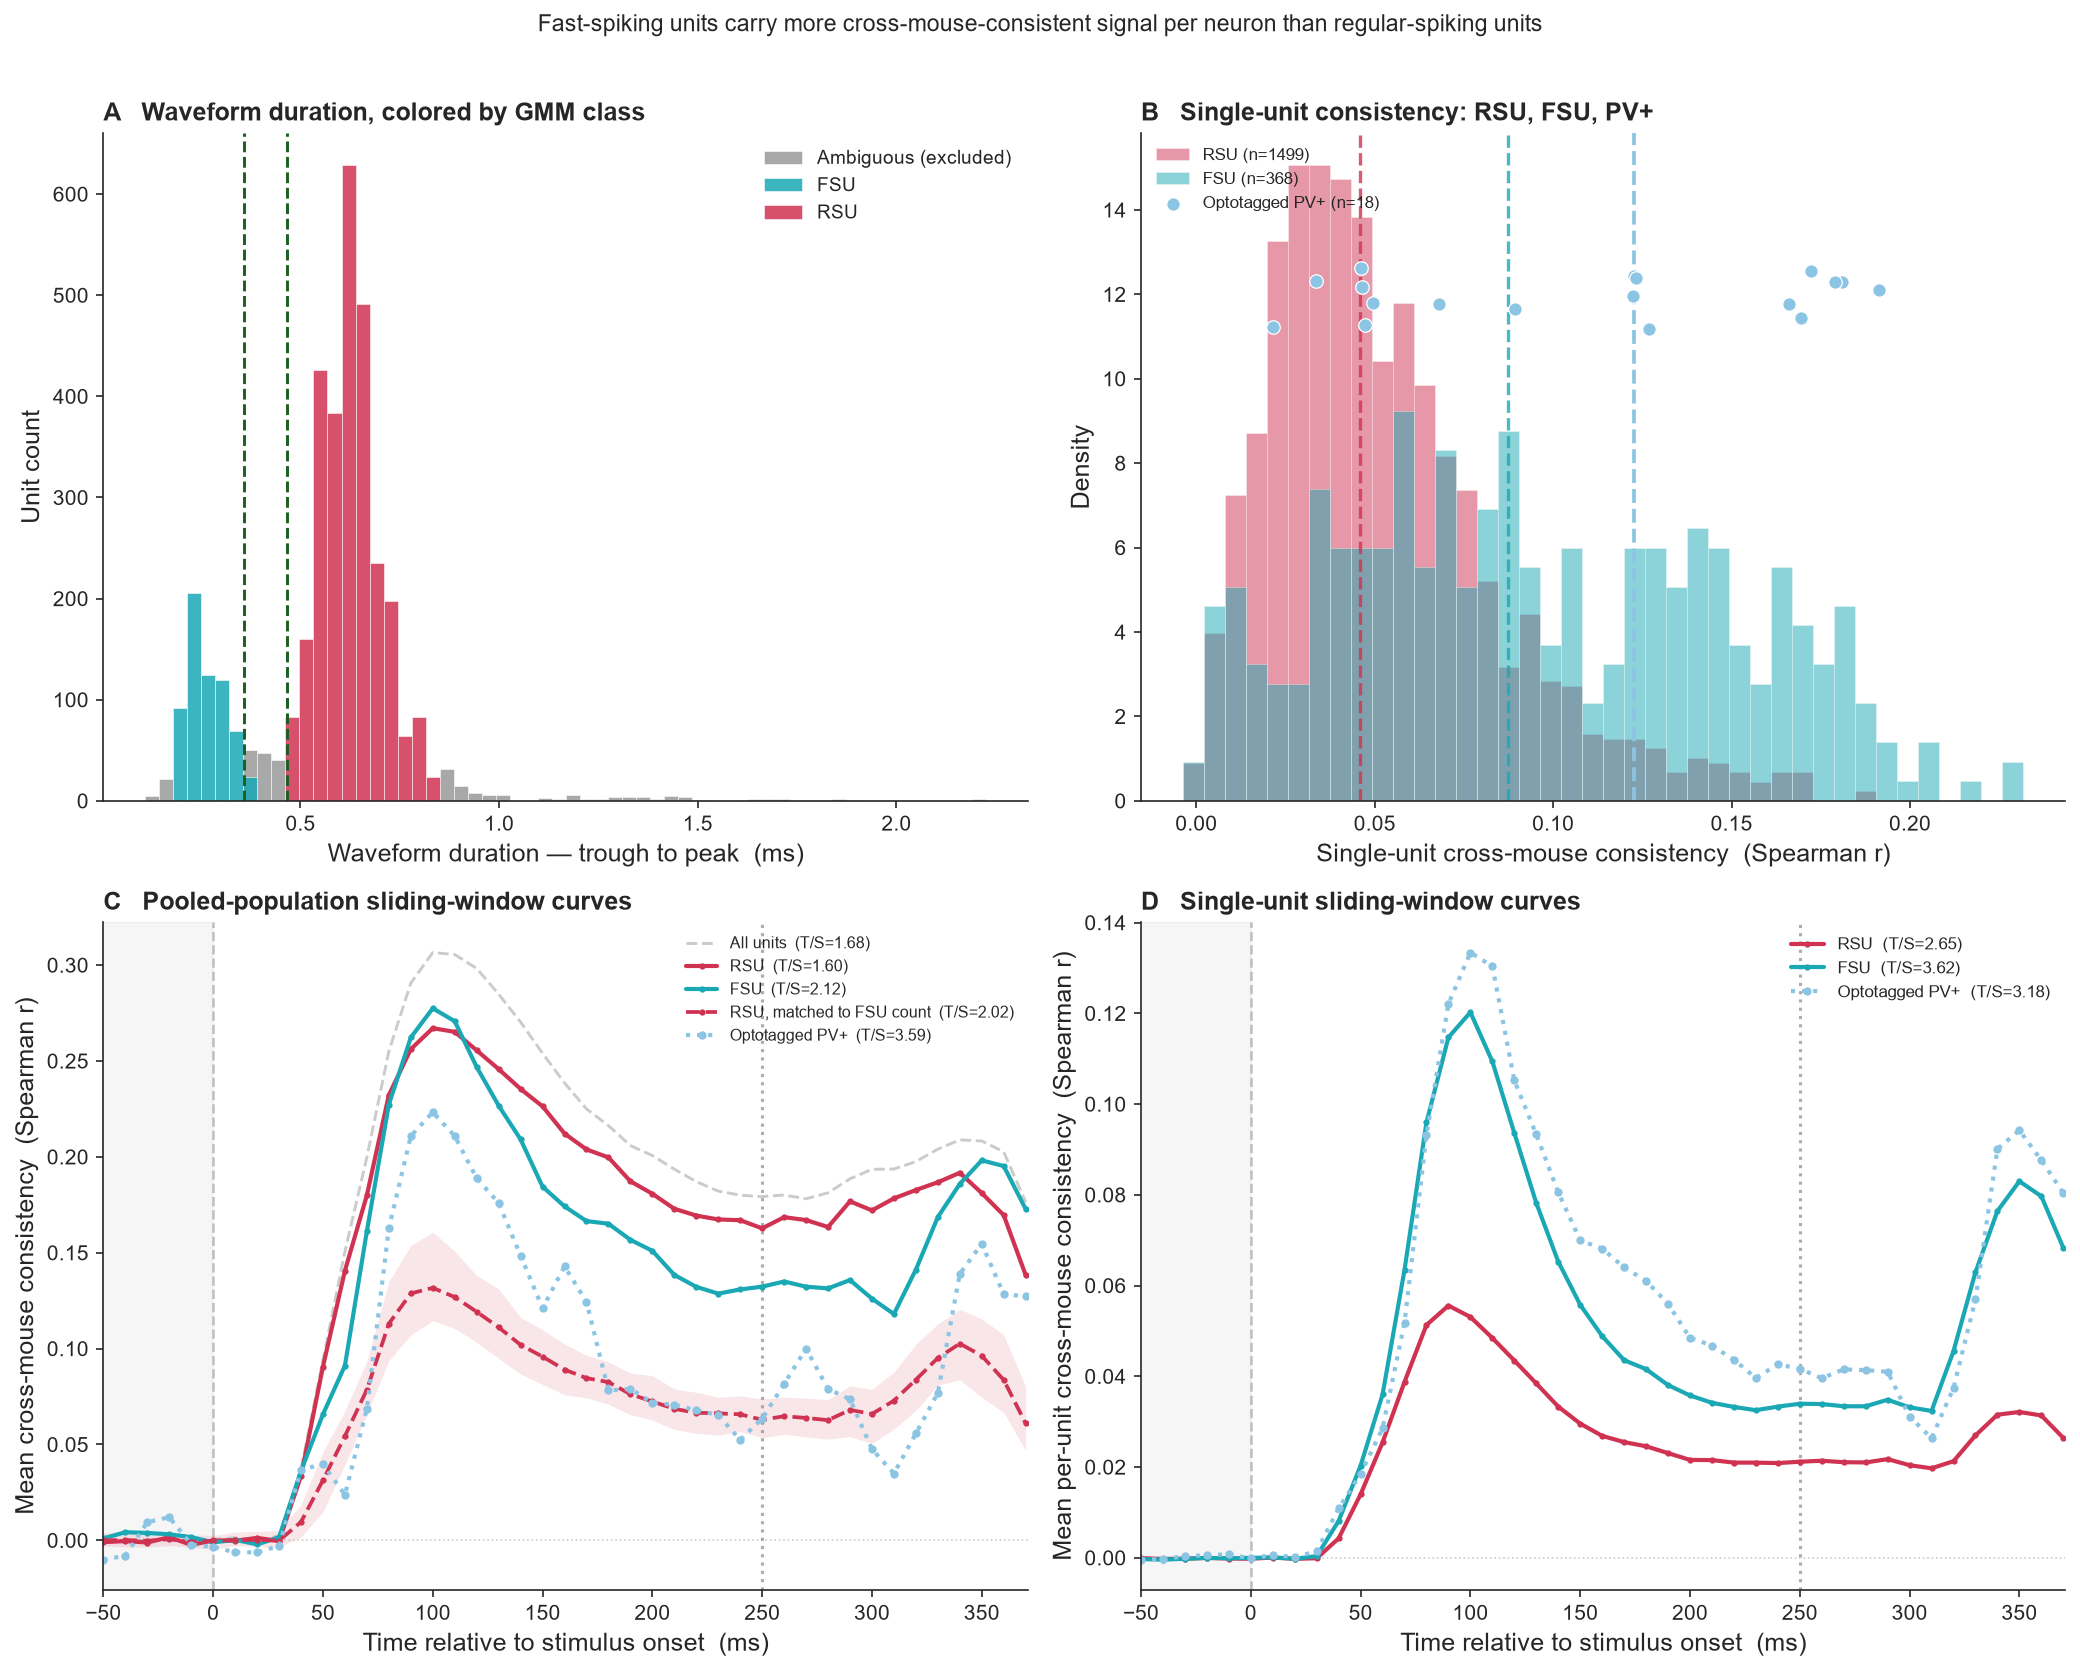

In [21]:
fig = plt.figure(figsize=(14, 11))
ax_wf_hist = fig.add_subplot(2, 2, 1)
ax_su_hist = fig.add_subplot(2, 2, 2)
ax_pop     = fig.add_subplot(2, 2, 3)
ax_su      = fig.add_subplot(2, 2, 4)

text_bbox = dict(facecolor='white', alpha=0.7, edgecolor='none')

def setup_time_ax(ax):
    ax.axvspan(SLIDE_START_MS, 0, color='gray', alpha=0.07)
    ax.axvline(0,   color=COL_REF, linestyle='--', linewidth=1.2, alpha=0.6)
    ax.axvline(250, color=COL_REF, linestyle=':',  linewidth=1.5, alpha=0.8)
    ax.axhline(0,   color='gray',  linestyle=':',  linewidth=0.8, alpha=0.4)
    ax.set_xlabel('Time relative to stimulus onset  (ms)')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
    ax.set_xlim(SLIDE_START_MS, SLIDE_END_MS)
    ax.spines[['top', 'right']].set_visible(False)

# ── Panel A: waveform duration histogram, colored by classification ─────────
wf_vals   = visp_wf['waveform_duration'].dropna()
hist_bins_wf = np.histogram_bin_edges(wf_vals, bins=60)

ax_wf_hist.hist(visp_wf.loc[visp_wf['cell_class'] == 'ambiguous', 'waveform_duration'],
                bins=hist_bins_wf, color=COL_REF, alpha=0.85,
                edgecolor='white', linewidth=0.3, label='Ambiguous (excluded)')
ax_wf_hist.hist(visp_wf.loc[visp_wf['cell_class'] == 'FSU', 'waveform_duration'],
                bins=hist_bins_wf, color=COL_FSU, alpha=0.85,
                edgecolor='white', linewidth=0.3, label='FSU')
ax_wf_hist.hist(visp_wf.loc[visp_wf['cell_class'] == 'RSU', 'waveform_duration'],
                bins=hist_bins_wf, color=COL_RSU, alpha=0.85,
                edgecolor='white', linewidth=0.3, label='RSU')
ax_wf_hist.axvline(narrow_edge, color=COL_FIT, linestyle='--', linewidth=1.4)
ax_wf_hist.axvline(broad_edge,  color=COL_FIT, linestyle='--', linewidth=1.4)
ax_wf_hist.set_xlabel('Waveform duration — trough to peak  (ms)')
ax_wf_hist.set_ylabel('Unit count')
ax_wf_hist.legend(frameon=False, fontsize=9)
ax_wf_hist.set_title('A   Waveform duration, colored by GMM class',
                      loc='left', fontweight='bold', pad=6)
ax_wf_hist.spines[['top', 'right']].set_visible(False)

# ── Panel B: single-unit consistency distributions, FSU/RSU/PV+ ─────────────
hist_bins_su = np.histogram_bin_edges(np.concatenate([fsu_scores, rsu_scores]), bins=40)

ax_su_hist.hist(rsu_scores, bins=hist_bins_su, color=COL_RSU, alpha=0.5, density=True,
                edgecolor='white', linewidth=0.3, label=f'RSU (n={len(rsu_scores)})')
ax_su_hist.hist(fsu_scores, bins=hist_bins_su, color=COL_FSU, alpha=0.5, density=True,
                edgecolor='white', linewidth=0.3, label=f'FSU (n={len(fsu_scores)})')
ax_su_hist.axvline(np.median(rsu_scores),  color=COL_RSU,    linestyle='--', linewidth=1.6, alpha=0.8)
ax_su_hist.axvline(np.median(fsu_scores),  color=COL_FSU,    linestyle='--', linewidth=1.6, alpha=0.8)
ax_su_hist.axvline(np.median(opto_scores), color=COL_FSU_PV, linestyle='--', linewidth=1.8)

ymax_su = ax_su_hist.get_ylim()[1]
rng_jit = np.random.default_rng(SEED)
rug_y   = rng_jit.uniform(0.70 * ymax_su, 0.80 * ymax_su, size=len(opto_scores))
ax_su_hist.scatter(opto_scores, rug_y, marker='o', s=42, color=COL_FSU_PV,
                    edgecolor='white', linewidth=0.6, zorder=5,
                    label=f'Optotagged PV+ (n={len(opto_scores)})')
ax_su_hist.set_xlabel('Single-unit cross-mouse consistency  (Spearman r)')
ax_su_hist.set_ylabel('Density')
ax_su_hist.legend(frameon=False, fontsize=8, loc='upper left')
ax_su_hist.set_title('B   Single-unit consistency: RSU, FSU, PV+',
                      loc='left', fontweight='bold', pad=6)
ax_su_hist.spines[['top', 'right']].set_visible(False)

# ── Panel C: population-level sliding-window curves ──────────────────────────
setup_time_ax(ax_pop)
ax_pop.plot(times_ms, mean_c, color=COL_REF, linewidth=1.4, linestyle='--', alpha=0.5,
            label=f'All units  (T/S={ts_ratio_all:.2f})')
ax_pop.plot(ts_rsu, mc_rsu, color=COL_RSU, linewidth=2.0, marker='o', markersize=2,
            label=f'RSU  (T/S={ts_ratio_rsu:.2f})')
ax_pop.plot(ts_fsu, mc_fsu, color=COL_FSU, linewidth=2.0, marker='o', markersize=2,
            label=f'FSU  (T/S={ts_ratio_fsu:.2f})')
ax_pop.plot(ts_rsu_match, mc_rsu_match, color=COL_RSU, linewidth=1.8, linestyle='--',
            marker='o', markersize=2,
            label=f'RSU, matched to FSU count  (T/S={ts_ratio_rsu_match:.2f})')
ax_pop.fill_between(ts_rsu_match, ci_lo_rsu_match, ci_hi_rsu_match, color=COL_RSU, alpha=0.12, linewidth=0)
ax_pop.plot(ts_pv, mc_pv, color=COL_FSU_PV, linewidth=2.0, linestyle=':',
            marker='o', markersize=3,
            label=f'Optotagged PV+  (T/S={ts_ratio_pv:.2f})')
ax_pop.set_ylabel('Mean cross-mouse consistency  (Spearman r)')
ax_pop.legend(frameon=False, fontsize=7.5)
ax_pop.set_title('C   Pooled-population sliding-window curves', loc='left', fontweight='bold', pad=6)

# ── Panel D: single-unit sliding-window curves ───────────────────────────────
setup_time_ax(ax_su)
ax_su.plot(ts_su, mc_rsu_su, color=COL_RSU, linewidth=2.0, marker='o', markersize=2,
           label=f'RSU  (T/S={ts_ratio_rsu_su:.2f})')
ax_su.plot(ts_su, mc_fsu_su, color=COL_FSU, linewidth=2.0, marker='o', markersize=2,
           label=f'FSU  (T/S={ts_ratio_fsu_su:.2f})')
ax_su.plot(ts_opto_su, mc_opto_su, color=COL_FSU_PV, linewidth=2.0, linestyle=':',
           marker='o', markersize=3,
           label=f'Optotagged PV+  (T/S={ts_ratio_opto_su:.2f})')
ax_su.set_ylabel('Mean per-unit cross-mouse consistency  (Spearman r)')
ax_su.legend(frameon=False, fontsize=8)
ax_su.set_title('D   Single-unit sliding-window curves', loc='left', fontweight='bold', pad=6)

fig.suptitle('Fast-spiking units carry more cross-mouse-consistent signal per neuron than regular-spiking units',
             fontsize=11, y=1.01)

print_figure_data(
    'Fig 5A — waveform duration distribution by GMM class',
    waveform_duration_ms=wf_vals.to_numpy(),
    narrow_class_boundary_ms=np.array(narrow_edge),
    broad_class_boundary_ms=np.array(broad_edge),
    n_fsu_total=np.array(n_fsu_total),
    n_rsu_total=np.array(n_rsu_total),
    n_ambiguous_total=np.array(n_amb_total),
)
print_figure_data(
    'Fig 5B — single-unit consistency distributions',
    fsu_scores=fsu_scores,
    rsu_scores=rsu_scores,
    opto_scores=opto_scores,
    opto_classes=opto_classes,
)
print_figure_data(
    'Fig 5C — pooled-population sliding-window curves',
    all_units_times_ms=times_ms, all_units_mean_consistency=mean_c,
    rsu_times_ms=ts_rsu, rsu_mean_consistency=mc_rsu,
    fsu_times_ms=ts_fsu, fsu_mean_consistency=mc_fsu,
    rsu_matched_times_ms=ts_rsu_match, rsu_matched_mean_consistency=mc_rsu_match,
    pv_times_ms=ts_pv, pv_mean_consistency=mc_pv,
)
print_figure_data(
    'Fig 5D — single-unit sliding-window curves',
    times_ms=ts_su,
    rsu_mean_consistency=mc_rsu_su,
    fsu_mean_consistency=mc_fsu_su,
    pv_times_ms=ts_opto_su,
    pv_mean_consistency=mc_opto_su,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_cell_type_dissociation.png', bbox_inches='tight')
plt.show()

---
## Supplementary Figure

**Fig. S5** — 1: session-level FSU-fraction split (pooled population,
same confounds as Fig 5C). 2: optotagged PV+ waveform duration by session.
3: GMM class vs. optotagging confusion matrix. 4: single-unit consistency
vs. response magnitude, by class.


Fig S4.1 — high vs. low FSU-fraction session groups

--- high_times_ms ---
shape=(43,)
[-50 -40 -30 -20 -10   0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]
...[43 elements total]

--- high_mean_consistency ---
shape=(43,)
[ 0.000631  0.000958  0.001875  0.001535  0.000855  0.001026  0.00063  -0.000807  0.001643  0.024199  0.063911  0.110965  0.158364  0.222656  0.267724  0.288753  0.28747   0.278178  0.263842
  0.250097]
...[43 elements total]

--- low_times_ms ---
shape=(43,)
[-50 -40 -30 -20 -10   0  10  20  30  40  50  60  70  80  90 100 110 120 130 140]
...[43 elements total]

--- low_mean_consistency ---
shape=(43,)
[-0.001328 -0.000822 -0.000538  0.001134 -0.000805  0.000264  0.004402 -0.000313  0.003771  0.053636  0.12624   0.191895  0.239017  0.284323  0.311877  0.323679  0.322389  0.315641  0.304558
  0.289193]
...[43 elements total]

--- low_matched_times_ms ---
shape=(43,)
[-50. -40. -30. -20. -10.   0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120

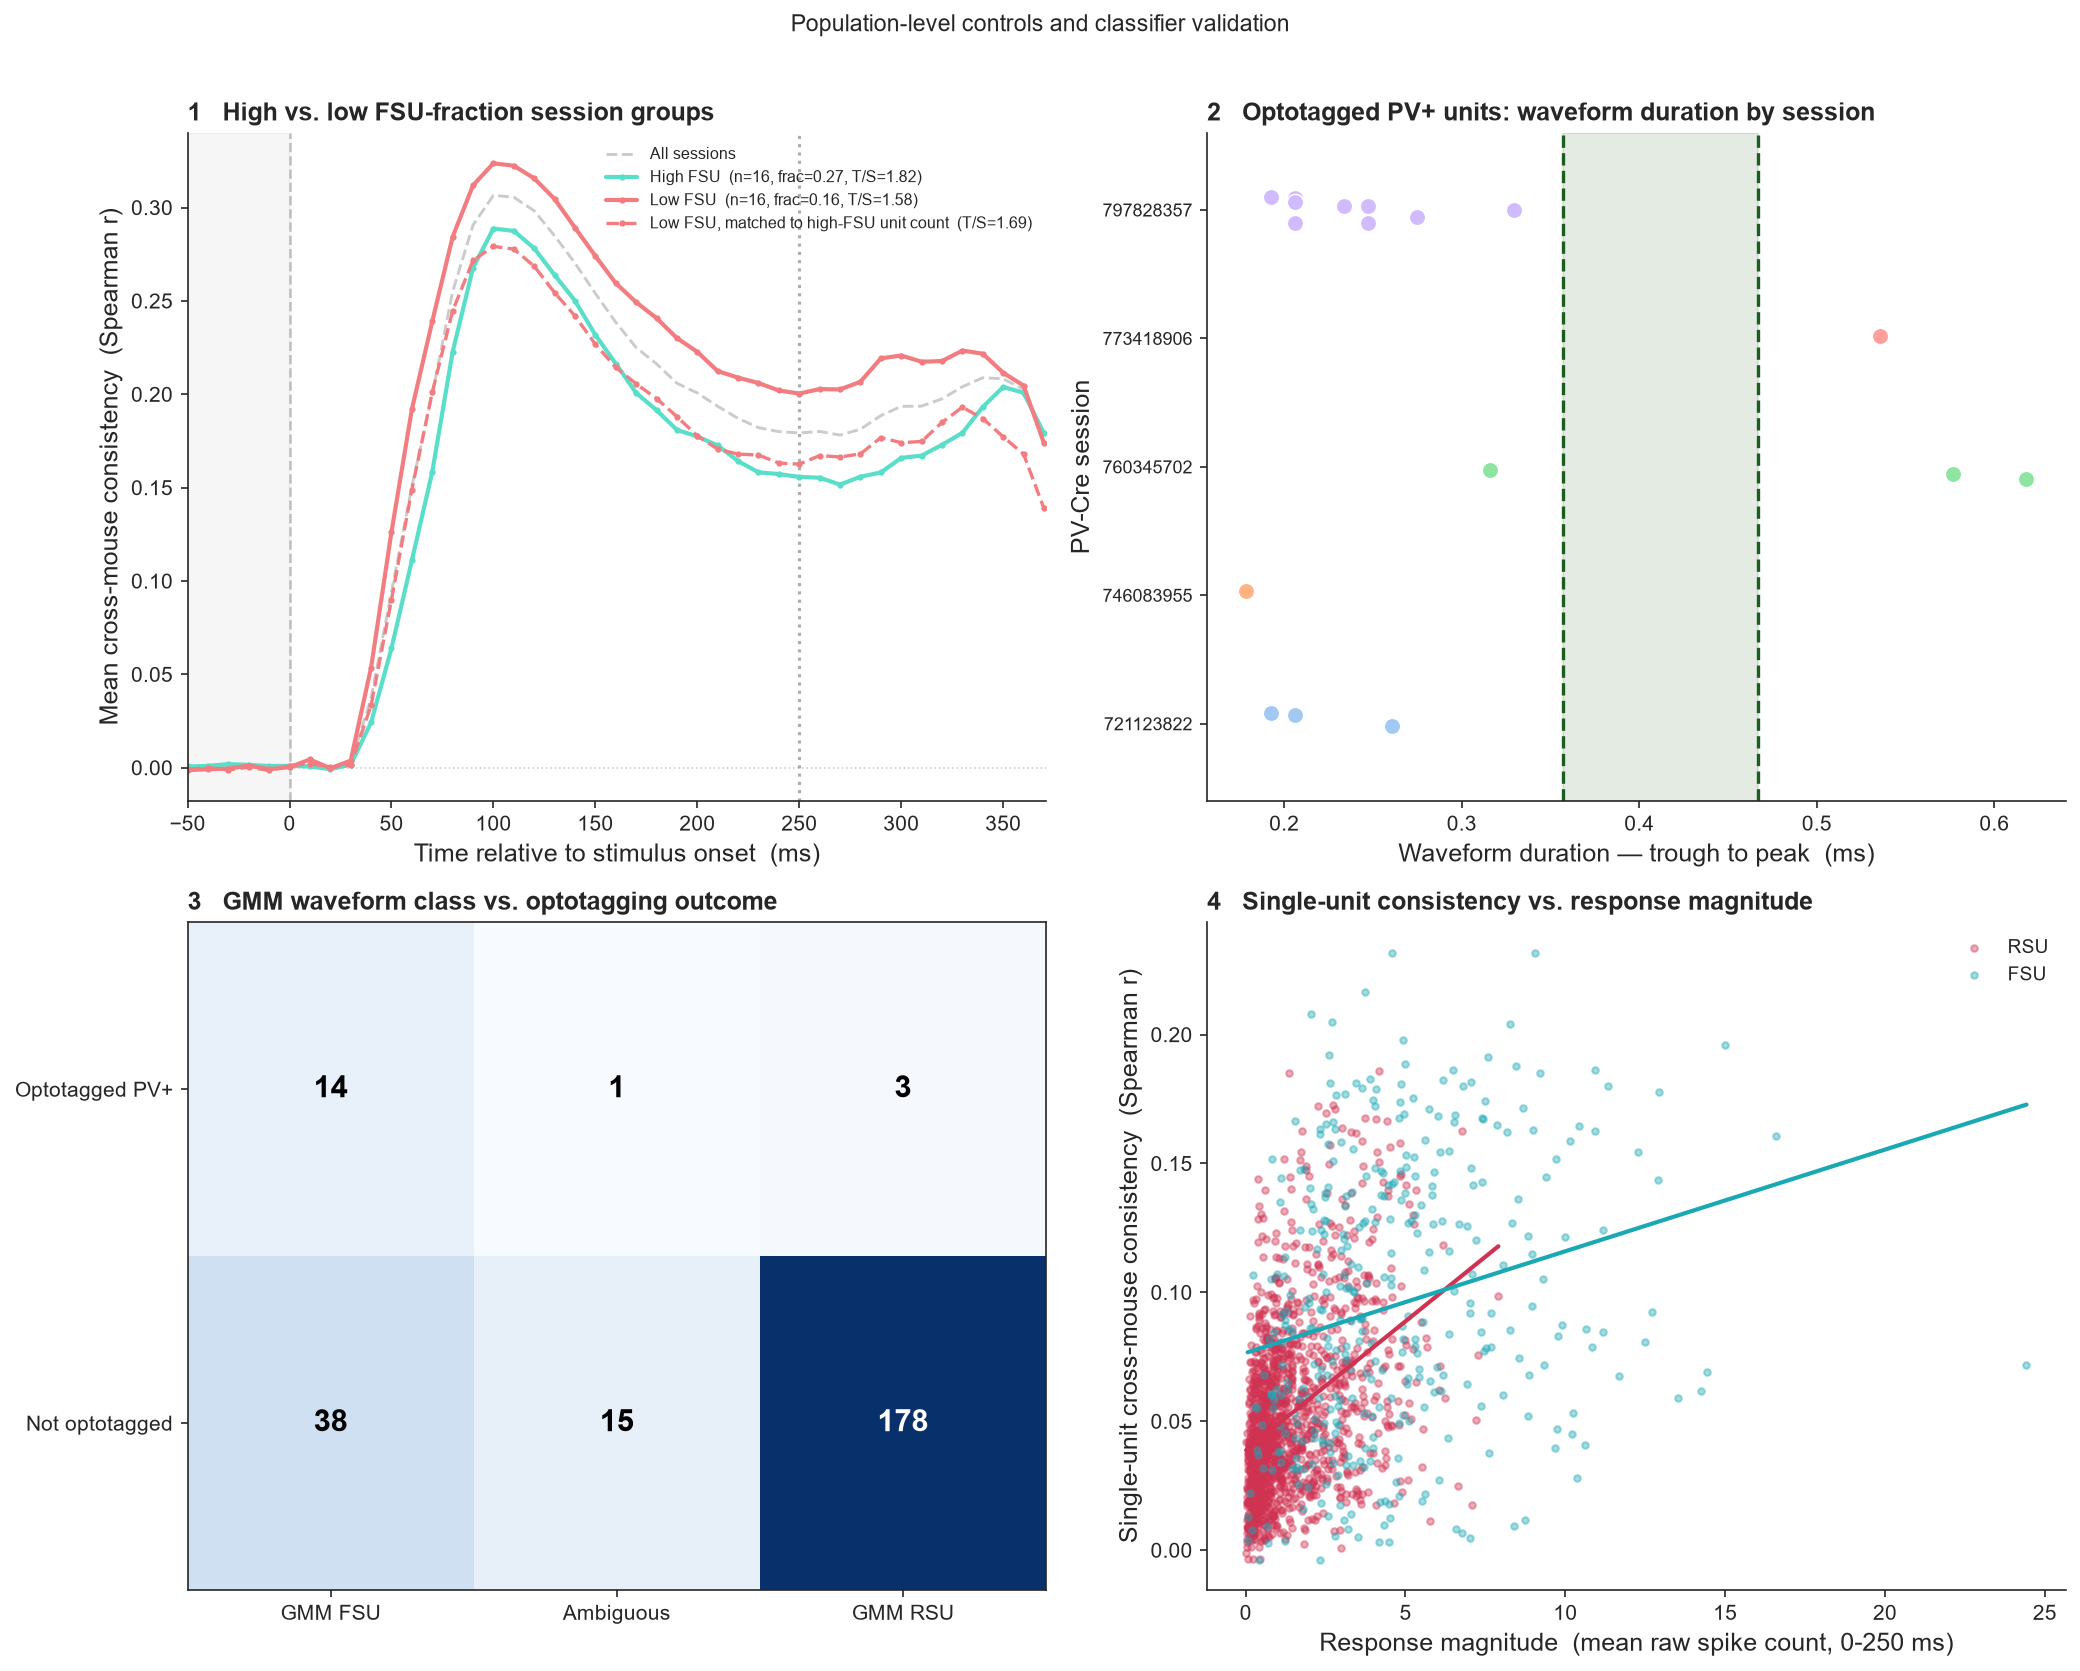

In [24]:
fig_s5 = plt.figure(figsize=(14, 11))
ax_split = fig_s5.add_subplot(2, 2, 1)
ax_strip = fig_s5.add_subplot(2, 2, 2)
ax_conf  = fig_s5.add_subplot(2, 2, 3)
ax_mag   = fig_s5.add_subplot(2, 2, 4)

text_bbox = dict(facecolor='white', alpha=0.7, edgecolor='none')

# ── Panel 1: high vs. low FSU-fraction session groups ────────────────────────
ax_split.axvspan(SLIDE_START_MS, 0, color='gray', alpha=0.07)
ax_split.axvline(0,   color=COL_REF, linestyle='--', linewidth=1.2, alpha=0.6)
ax_split.axvline(250, color=COL_REF, linestyle=':',  linewidth=1.5, alpha=0.8)
ax_split.axhline(0,   color='gray',  linestyle=':',  linewidth=0.8, alpha=0.4)
ax_split.plot(times_ms, mean_c, color=COL_REF, linewidth=1.4, linestyle='--', alpha=0.5,
              label='All sessions')
ax_split.plot(ts_high, mc_high, color=COL_HIGH_FSU_FRAC, linewidth=2.0, marker='o', markersize=2,
              label=f'High FSU  (n={len(high_fsu_sids)}, frac={mean_frac_high:.2f}, T/S={ts_ratio_high:.2f})')
ax_split.plot(ts_low, mc_low, color=COL_LOW_FSU_FRAC, linewidth=2.0, marker='o', markersize=2,
              label=f'Low FSU  (n={len(low_fsu_sids)}, frac={mean_frac_low:.2f}, T/S={ts_ratio_low:.2f})')
ax_split.plot(ts_low_match, mc_low_match, color=COL_LOW_FSU_FRAC, linewidth=1.6, linestyle='--',
              marker='o', markersize=2,
              label=f'Low FSU, matched to high-FSU unit count  (T/S={ts_ratio_low_match:.2f})')
ax_split.set_xlabel('Time relative to stimulus onset  (ms)')
ax_split.set_ylabel('Mean cross-mouse consistency  (Spearman r)')
ax_split.xaxis.set_major_locator(mticker.MultipleLocator(50))
ax_split.set_xlim(SLIDE_START_MS, SLIDE_END_MS)
ax_split.legend(frameon=False, fontsize=7.5)
ax_split.set_title('1   High vs. low FSU-fraction session groups', loc='left', fontweight='bold', pad=6)
ax_split.spines[['top', 'right']].set_visible(False)

# ── Panel 2: strip plot of optotagged units' waveform duration, by session ──
for row_i, sid in enumerate(PV_SESSION_IDS):
    sess_tagged = tagged_pv[tagged_pv['ecephys_session_id'] == sid]
    jitter = np.random.default_rng(SEED + row_i).uniform(-0.12, 0.12, size=len(sess_tagged))
    ax_strip.scatter(sess_tagged['waveform_duration'], row_i + jitter,
                      s=60, color=session_colors[sid], edgecolor='white',
                      linewidth=0.6, zorder=3, label=f'{sid} (n={len(sess_tagged)})')
ax_strip.axvspan(narrow_edge, broad_edge, color=COL_FIT, alpha=0.12, zorder=1)
ax_strip.axvline(narrow_edge, color=COL_FIT, linestyle='--', linewidth=1.6, zorder=2)
ax_strip.axvline(broad_edge,  color=COL_FIT, linestyle='--', linewidth=1.6, zorder=2)
ax_strip.set_yticks(range(len(PV_SESSION_IDS)))
ax_strip.set_yticklabels([str(s) for s in PV_SESSION_IDS], fontsize=8.5)
ax_strip.set_xlabel('Waveform duration — trough to peak  (ms)')
ax_strip.set_ylabel('PV-Cre session')
ax_strip.set_title('2   Optotagged PV+ units: waveform duration by session',
                    loc='left', fontweight='bold', pad=6)
ax_strip.spines[['top', 'right']].set_visible(False)
ax_strip.set_ylim(-0.6, len(PV_SESSION_IDS) - 0.4)

# ── Panel 3: confusion matrix — opto tag vs. GMM waveform class ─────────────
im = ax_conf.imshow(conf.values, cmap='Blues', aspect='auto', interpolation='nearest')
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        val = conf.values[i, j]
        txt_color = 'white' if val > conf.values.max() * 0.55 else 'black'
        ax_conf.text(j, i, f'{val}', ha='center', va='center',
                     fontsize=15, fontweight='bold', color=txt_color)
ax_conf.set_xticks(range(conf.shape[1]))
ax_conf.set_xticklabels(['GMM FSU', 'Ambiguous', 'GMM RSU'])
ax_conf.set_yticks([0, 1]); ax_conf.set_yticklabels(conf.index)
ax_conf.set_title('3   GMM waveform class vs. optotagging outcome', loc='left', fontweight='bold', pad=6)

# ── Panel 4: single-unit consistency vs. magnitude, by class ────────────────
for cls, col in [('RSU', COL_RSU), ('FSU', COL_FSU)]:
    sel = unit_classes == cls
    ax_mag.scatter(unit_magnitude[sel], unit_scores[sel], s=10, color=col, alpha=0.4, label=cls)
    coef = np.polyfit(unit_magnitude[sel], unit_scores[sel], 1)
    xs = np.linspace(unit_magnitude[sel].min(), unit_magnitude[sel].max(), 50)
    ax_mag.plot(xs, np.polyval(coef, xs), color=col, linewidth=2)
ax_mag.set_xlabel('Response magnitude  (mean raw spike count, 0-250 ms)')
ax_mag.set_ylabel('Single-unit cross-mouse consistency  (Spearman r)')
ax_mag.legend(frameon=False, fontsize=9)
ax_mag.set_title('4   Single-unit consistency vs. response magnitude', loc='left', fontweight='bold', pad=6)
ax_mag.spines[['top', 'right']].set_visible(False)

fig_s5.suptitle('Population-level controls and classifier validation', fontsize=11, y=1.01)

print_figure_data(
    'Fig S4.1 — high vs. low FSU-fraction session groups',
    high_times_ms=ts_high, high_mean_consistency=mc_high,
    low_times_ms=ts_low, low_mean_consistency=mc_low,
    low_matched_times_ms=ts_low_match, low_matched_mean_consistency=mc_low_match,
)
print_figure_data(
    'Fig S4.2 — optotagged PV+ waveform durations by session',
    session_ids=np.array(PV_SESSION_IDS),
    waveform_duration_ms=tagged_pv['waveform_duration'].to_numpy(),
)
print_figure_data(
    'Fig S4.3 — confusion matrix: optotagging vs. waveform class',
    confusion_matrix=conf.values,
    row_labels=np.array(conf.index.tolist()),
    col_labels=np.array(conf.columns.tolist()),
    sensitivity_pv_to_fsu=np.array(sensitivity),
    precision_fsu_to_pv=np.array(fsu_precision),
)
print_figure_data(
    'Fig S4.4 — single-unit consistency vs. magnitude, by class',
    unit_magnitude=unit_magnitude,
    unit_scores=unit_scores,
    unit_classes=unit_classes,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'figS4_population_controls_and_validation.png', bbox_inches='tight')
plt.show()